In [1]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [2]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../../')
# Import list
from imports import *
# Parameter list
import param as pm

In [3]:
# Returning the date/time of observation or unix time
fname, dtime=tools.timepoint(fname=pm.file, date=None)

fs_slice=1250
fe_slice=1305

folder = 'single_antenna_test/'

Date of observation: 2019-02-25 02:40:11
Fname: 1551055211


In [4]:
def radiometer_eq(data):
    '''
    Radiometer euquation for determining the error on the data
    '''
    d_nu = 0.2 * 10**6 # Hz
    d_t = 2 # s
    n_pol = 2 
    n_dish = 58
    sig2 = data**2 / (n_pol*d_nu*d_t*n_dish)
    sig = np.sqrt(sig2)
    
    return sig


In [5]:
sat = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs, pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=True)




1551055211-Satellite angular seperation not found :(


TypeError: 'NoneType' object is not iterable

In [6]:
pm.nearby_constellations


'/idia/projects/hi_im/brandon/meerkat_gain_cali/1551055211/nearby_satellites/nearby_satellite_close_angle_5_fill.p'

In [6]:
np.random.seed()
dic = 5*np.random.random(5)
ts=12
sat.excecute(a_param=dic, 
                 obs_time_start=pm.nd_s0[ts*100], obs_time_end=pm.nd_s0[ts*100+100], 
                 obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None,
                 verbose=False)

In [7]:
sat.frequency_idx

(1196, 1461)

In [8]:
ext_fs = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]] , sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


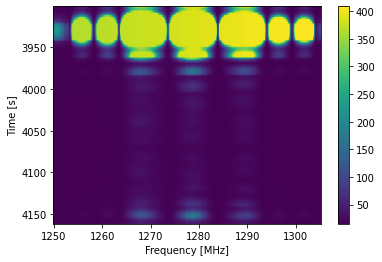

In [9]:
plt.imshow(sat.calibration_data_slice.T, aspect='auto', extent=ext_fs)
plt.ylabel('Time [s]')
plt.xlabel('Frequency [MHz]')
plt.colorbar()

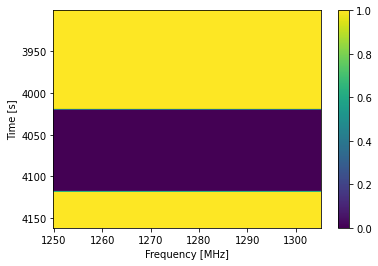

In [10]:
plt.imshow(sat.mask_nearby_satellites_slice, aspect='auto', extent=ext_fs)
plt.ylabel('Time [s]')
plt.xlabel('Frequency [MHz]')
plt.colorbar()

In [11]:
simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)

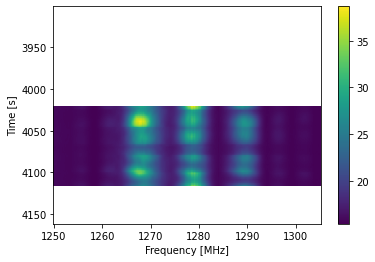

In [12]:
plt.imshow(data, aspect='auto', extent=ext_fs)
plt.ylabel('Time [s]')
plt.xlabel('Frequency [MHz]')
plt.colorbar()

In [13]:
def sat_sim_p(ts, queue):

    num = 'chunk'+'_'+str(ts)
    print ('Starting: '+str(num))
    # 1st initialization
    sat = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs, pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=False)
    
    np.random.seed()
    dic = 10*np.random.random(5)

    sat.excecute(a_param=dic, 
                 obs_time_start=pm.nd_s0[ts*100], obs_time_end=pm.nd_s0[ts*100+100], 
                 obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None,
                 verbose=False) 

    def chisq_func2(a_param):
        """
        Chi2 function which will take in all the parameters for the satellites
        """

        sat.excecute(a_param=dic, 
                 obs_time_start=pm.nd_s0[ts*100], obs_time_end=pm.nd_s0[ts*100+100], 
                 obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None,
                 verbose=False)


        # # No mask
        # simulation = sat.simulation_TOD_slice
        # data = sat.calibration_data_slice
        
        # Masked
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)
        
        # # Averaging 10sec over
        # bins=np.arange(nd_s0[ts*100], nd_s0[ts*100+100], 10)   # 10 represents 10sec
        # inds = np.digitize(x=nd_s0[ts*100:ts*100+100+1], bins=bins)
        # #
        # simulation_avg = np.ma.array([simulation[:, inds==i].mean(axis=1) for i in np.unique(inds)])
        # data_avg = np.ma.array([data[:, inds==i].mean(axis=1) for i in np.unique(inds)])
        
        sig = radiometer_eq(data=data)    

        chi_sq = np.ma.sum((simulation - data)**2 / sig**2)
        return chi_sq

    # Priors/Bounds
    bnd_val = (0.0, 30)
    bnds = [bnd_val for bnd_i in range(sat.alpha_len)]

    # Optimization
    print ('Running optimization: '+str(num))
    signal_PL = opt.minimize(fun=chisq_func2, 
                             x0=dic, 
                             method='Powell',
                             bounds=bnds, 
                             tol=1e-6, 
                             options={'maxiter':20})

    # 2nd initilization  
    print ('Running 2nd step: '+str(num))
    sat2 = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs, pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=False)

    sat2.excecute(a_param=signal_PL.x, 
                    obs_time_start=pm.nd_s0[ts*100], obs_time_end=pm.nd_s0[ts*100+100], 
                    obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                    file_bias_choice=pm.bias, 
                    add_sub=[1, 1], 
                    band_lvl=[None, None], 
                    bandsize=None,
                    verbose=False)

   
    # Storing the data
    print ('Storing: '+str(num))
    data_info = {'initial':dic,
                 'time': sat.nd_s0[ts*100:ts*100+100+1],
                 'best-fit':signal_PL.x,
                 'chi2_value':signal_PL.fun,
                 'chi2_div':signal_PL.fun/sat2.simulation_TOD_slice.size}
    
    
    pickle.dump(data_info, open(pm.data_save+folder+'parallel_5deg_mask_satellite_'+str(num)+'_f_'+str(pm.fs)+'_'+str(pm.fe)+'MHz__'+str(fs_slice)+'_'+str(fe_slice)+'MHz_v2.p', 'wb'))


    print (num+' End')
    

In [14]:
mp.cpu_count()

32

In [18]:
time.asctime(time.localtime(time.time()))

'Wed Jun 29 12:11:18 2022'

In [19]:
if __name__ == '__main__':

    procs = 1
    
    queue = mp.Queue()
    
    processes = [mp.Process(target=sat_sim_p,  args=(intv, queue)) for intv in range(0,procs,1)]
    
    
    for prs in processes:
        prs.start()

    for prs in processes:
        prs.join()

Starting: chunk_0


KeyboardInterrupt: 

Running optimization: chunk_0
Running 2nd step: chunk_0
Storing: chunk_0
chunk_0 End


In [17]:
time.asctime(time.localtime(time.time()))

'Wed Jun 29 11:47:24 2022'